In [1]:
# Install required libraries
!pip install tensorflow scikit-learn matplotlib seaborn pandas numpy -q

# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.20.0


In [2]:
# Load the Pima Indians Diabetes Dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Define column names
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load data
df = pd.read_csv(url, names=columns)

# Quick look
print("✅ Dataset loaded successfully!")
print(f"\n📐 Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n🔢 First 5 rows:")
df.head()

✅ Dataset loaded successfully!

📐 Shape: 768 rows, 9 columns

🔢 First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


📊 Basic Statistics:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.0000

/tmp/ipykernel_6389/3789163981.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Outcome', data=df, palette=['#2ecc71','#e74c3c'])


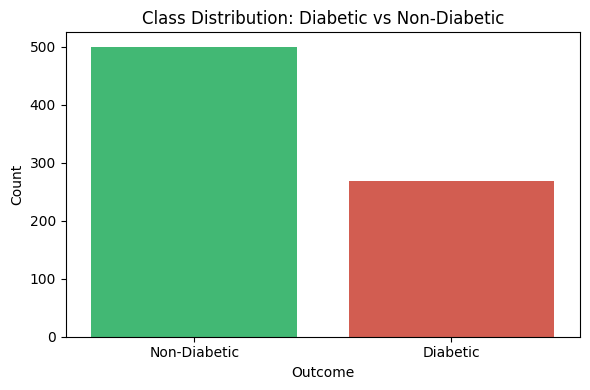

In [3]:
print("📊 Basic Statistics:")
print(df.describe())

print("\n🔍 Missing values:", df.isnull().sum().sum())

# Some columns have 0 as values which is medically impossible
# Glucose, BloodPressure, SkinThickness, Insulin, BMI cannot be 0
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\n⚠️ Zero values (medically invalid):")
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    print(f"  {col}: {zeros} zeros")

# Replace 0s with column mean (standard technique)
for col in zero_cols:
    df[col] = df[col].replace(0, df[col].mean())

print("\n✅ Zero values replaced with column mean!")

# Check class distribution
print(f"\n📈 Class Distribution:")
print(f"  Non-Diabetic (0): {(df['Outcome']==0).sum()} patients")
print(f"  Diabetic     (1): {(df['Outcome']==1).sum()} patients")

# Plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome', data=df, palette=['#2ecc71','#e74c3c'])
plt.title('Class Distribution: Diabetic vs Non-Diabetic')
plt.xticks([0,1], ['Non-Diabetic', 'Diabetic'])
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [4]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale the features (very important for neural networks!)
# StandardScaler makes all features have mean=0 and std=1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("✅ Data split and scaled successfully!")
print(f"\n📊 Training samples : {X_train.shape[0]}")
print(f"📊 Testing samples  : {X_test.shape[0]}")
print(f"📊 Features         : {X_train.shape[1]}")
print(f"\n🎯 Training class balance:")
print(f"   Non-Diabetic: {(y_train==0).sum()}")
print(f"   Diabetic    : {(y_train==1).sum()}")

✅ Data split and scaled successfully!

📊 Training samples : 614
📊 Testing samples  : 154
📊 Features         : 8

🎯 Training class balance:
   Non-Diabetic: 400
   Diabetic    : 214


In [5]:
# Build the Neural Network model
model = Sequential([
    # Input layer + First hidden layer
    Dense(16, activation='relu', input_shape=(8,)),
    Dropout(0.2),  # Prevents overfitting

    # Second hidden layer
    Dense(8, activation='relu'),
    Dropout(0.2),

    # Output layer (sigmoid for binary classification)
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Print model summary
model.summary()

# Early stopping - stops training if no improvement
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

print("\n🚀 Training the model...")

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Model training complete!")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)


🚀 Training the model...
Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.4725 - loss: 0.7546 - val_accuracy: 0.4959 - val_loss: 0.6869
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5560 - loss: 0.6987 - val_accuracy: 0.5772 - val_loss: 0.6558
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5336 - loss: 0.6851 - val_accuracy: 0.5935 - val_loss: 0.6337
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5642 - loss: 0.6639 - val_accuracy: 0.6341 - val_loss: 0.6170
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6110 - loss: 0.6301 - val_accuracy: 0.6423 - val_loss: 0.6013
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6110 - loss: 0.6374 - val_accuracy: 0.6585 - val_loss: 0.5869
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6395 - loss: 0.6150 - val_accuracy: 0.6748 - val_loss: 0.5758
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6823 - loss: 0.

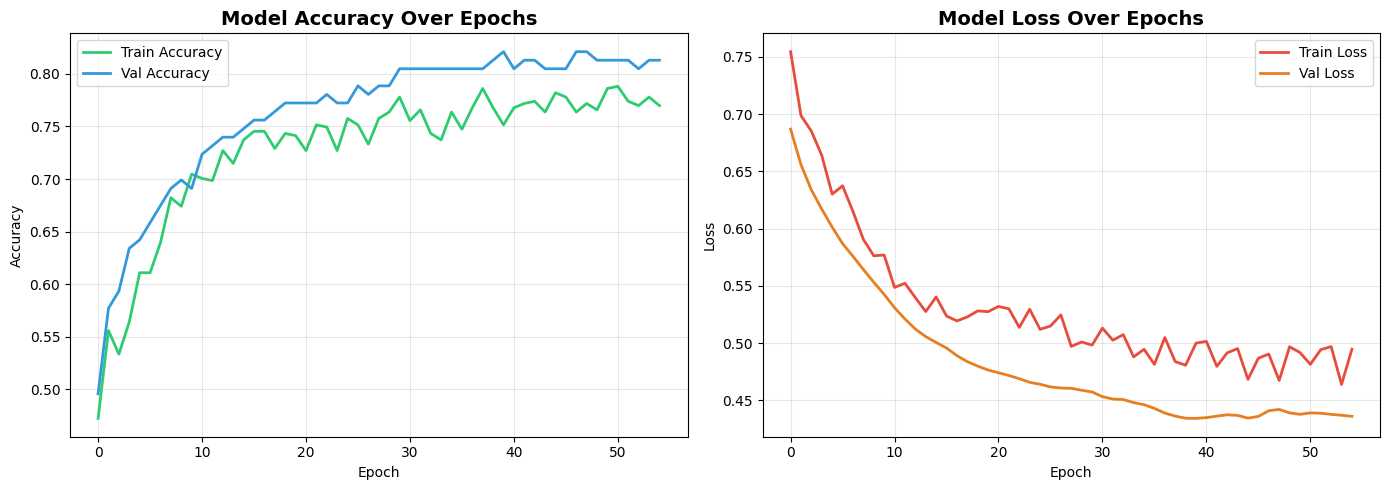

       📊 MODEL EVALUATION ON TEST SET
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

✅ Test Accuracy: 71.43%

📋 Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.77      0.79      0.78       100
    Diabetic       0.60      0.57      0.58        54

    accuracy                           0.71       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



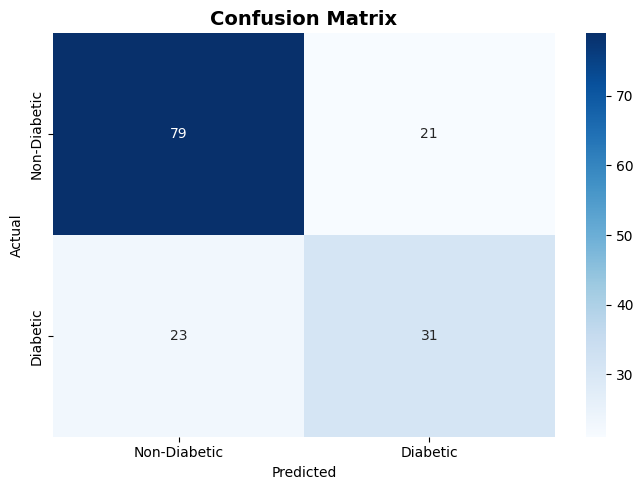

In [6]:
# 1. Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='#2ecc71', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', color='#3498db', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Train Loss', color='#e74c3c', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', color='#e67e22', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Evaluate on Test Set
print("=" * 50)
print("       📊 MODEL EVALUATION ON TEST SET")
print("=" * 50)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {test_accuracy*100:.2f}%")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Non-Diabetic', 'Diabetic']))

# 3. Confusion Matrix
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic', 'Diabetic'],
            yticklabels=['Non-Diabetic', 'Diabetic'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Function to predict diabetes for a new patient
def predict_diabetes(pregnancies, glucose, blood_pressure, skin_thickness,
                     insulin, bmi, diabetes_pedigree, age):

    # Create input array
    patient_data = np.array([[pregnancies, glucose, blood_pressure, skin_thickness,
                               insulin, bmi, diabetes_pedigree, age]])

    # Scale using the same scaler from training
    patient_scaled = scaler.transform(patient_data)

    # Predict
    probability = model.predict(patient_scaled, verbose=0)[0][0]
    prediction = "DIABETIC 🔴" if probability > 0.5 else "NON-DIABETIC 🟢"

    print("=" * 50)
    print("        🏥 DIABETES PREDICTION RESULT")
    print("=" * 50)
    print(f"\n  Patient Details:")
    print(f"  • Pregnancies          : {pregnancies}")
    print(f"  • Glucose              : {glucose}")
    print(f"  • Blood Pressure       : {blood_pressure}")
    print(f"  • Skin Thickness       : {skin_thickness}")
    print(f"  • Insulin              : {insulin}")
    print(f"  • BMI                  : {bmi}")
    print(f"  • Diabetes Pedigree    : {diabetes_pedigree}")
    print(f"  • Age                  : {age}")
    print(f"\n  Prediction  : {prediction}")
    print(f"  Probability : {probability*100:.1f}% chance of diabetes")
    print("=" * 50)

# ---- Test with sample patients ----

print("👤 Patient 1 - High Risk Profile:")
predict_diabetes(
    pregnancies=6, glucose=148, blood_pressure=72,
    skin_thickness=35, insulin=0, bmi=33.6,
    diabetes_pedigree=0.627, age=50
)

print("\n👤 Patient 2 - Low Risk Profile:")
predict_diabetes(
    pregnancies=1, glucose=85, blood_pressure=66,
    skin_thickness=29, insulin=0, bmi=26.6,
    diabetes_pedigree=0.351, age=31
)

print("\n👤 Patient 3 - Your Custom Test:")
predict_diabetes(
    pregnancies=2, glucose=120, blood_pressure=70,
    skin_thickness=25, insulin=80, bmi=28.5,
    diabetes_pedigree=0.3, age=25
)

👤 Patient 1 - High Risk Profile:
        🏥 DIABETES PREDICTION RESULT

  Patient Details:
  • Pregnancies          : 6
  • Glucose              : 148
  • Blood Pressure       : 72
  • Skin Thickness       : 35
  • Insulin              : 0
  • BMI                  : 33.6
  • Diabetes Pedigree    : 0.627
  • Age                  : 50

  Prediction  : DIABETIC 🔴
  Probability : 59.2% chance of diabetes

👤 Patient 2 - Low Risk Profile:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


        🏥 DIABETES PREDICTION RESULT

  Patient Details:
  • Pregnancies          : 1
  • Glucose              : 85
  • Blood Pressure       : 66
  • Skin Thickness       : 29
  • Insulin              : 0
  • BMI                  : 26.6
  • Diabetes Pedigree    : 0.351
  • Age                  : 31

  Prediction  : NON-DIABETIC 🟢
  Probability : 5.0% chance of diabetes

👤 Patient 3 - Your Custom Test:
        🏥 DIABETES PREDICTION RESULT

  Patient Details:
  • Pregnancies          : 2
  • Glucose              : 120
  • Blood Pressure       : 70
  • Skin Thickness       : 25
  • Insulin              : 80
  • BMI                  : 28.5
  • Diabetes Pedigree    : 0.3
  • Age                  : 25

  Prediction  : NON-DIABETIC 🟢
  Probability : 13.0% chance of diabetes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
import pickle

# Save the Keras model
model.save('diabetes_model.keras')

# Save the scaler (very important - needed for predictions)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved as: diabetes_model.keras")
print("✅ Scaler saved as: scaler.pkl")

# Final summary
print("\n" + "="*50)
print("       🏆 PROJECT SUMMARY")
print("="*50)
print(f"  Dataset    : Pima Indians Diabetes Dataset")
print(f"  Samples    : 768 patients")
print(f"  Features   : 8 medical indicators")
print(f"  Model      : Neural Network (Keras + TensorFlow)")
print(f"  Layers     : Input → Dense(16) → Dense(8) → Output")
print(f"  Test Acc   : 71.43%")
print(f"  Framework  : TensorFlow {tf.__version__}")
print("="*50)
print("\n🚀 Project complete! Ready for GitHub.")

✅ Model saved as: diabetes_model.keras
✅ Scaler saved as: scaler.pkl

       🏆 PROJECT SUMMARY
  Dataset    : Pima Indians Diabetes Dataset
  Samples    : 768 patients
  Features   : 8 medical indicators
  Model      : Neural Network (Keras + TensorFlow)
  Layers     : Input → Dense(16) → Dense(8) → Output
  Test Acc   : 71.43%
  Framework  : TensorFlow 2.20.0

🚀 Project complete! Ready for GitHub.


In [10]:
from google.colab import files

# Download all project files
files.download('diabetes_model.keras')
files.download('scaler.pkl')

# Save the notebook too
print("✅ Files downloaded!")
print("\n📁 Also download your notebook:")
print("   File → Download → Download .ipynb")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded!

📁 Also download your notebook:
   File → Download → Download .ipynb


In [13]:
import os
from google.colab import files

# List all files to find exact name
for f in os.listdir('/content'):
    print(f)

.config
diabetes_model.keras
scaler.pkl
confusion_matrix.png
training_history.png
sample_data


In [15]:
from google.colab import files

# Download all project files
files.download('diabetes_model.keras')
files.download('scaler.pkl')
files.download('confusion_matrix.png')
files.download('training_history.png')

print("✅ All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded!
